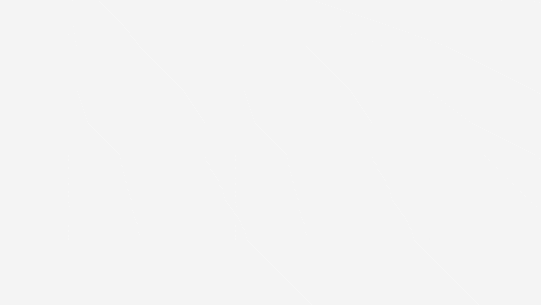

In [62]:
import pandas as pd  # to store data as dataframe
import numpy as np  # for numerical calculations such as histogramming
import matplotlib.pyplot as plt  # for plotting

In [63]:
seed_value = 420  # 42 is the answer to life, the universe and everything
from numpy.random import seed  # import the function to set the random seed in NumPy

seed(seed_value)  # set the seed value for random numbers in NumPy

In [64]:
# In this notebook we only process the main signal ggH125_ZZ4lep and the main background llll,
# for illustration purposes.
# You can add other backgrounds after if you wish.
samples = ["llll", "ggH125_ZZ4lep"]

In [65]:
# get data from files

DataFrames = {}  # define empty dictionary to hold dataframes
for s in samples:  # loop over samples
    DataFrames[s] = pd.read_csv("/kaggle/input/4lepton/" + s + ".csv")  # read .csv file

# DataFrames["ggH125_ZZ4lep"]  # print signal data to take a look

In [66]:
# cut on lepton type
def cut_lep_type(lep_type_0, lep_type_1, lep_type_2, lep_type_3):
    # first lepton is [0], 2nd lepton is [1] etc
    # for an electron lep_type is 11
    # for a muon lep_type is 13
    # only want to keep events where one of eeee, mumumumu, eemumu
    sum_lep_type = lep_type_0 + lep_type_1 + lep_type_2 + lep_type_3
    if sum_lep_type == 44 or sum_lep_type == 48 or sum_lep_type == 52:
        return True
    else:
        return False

In [67]:
# apply cut on lepton type
for s in samples:
    # cut on lepton type using the function cut_lep_type defined above
    DataFrames[s] = DataFrames[s][
        np.vectorize(cut_lep_type)(
            DataFrames[s].lep_type_0,
            DataFrames[s].lep_type_1,
            DataFrames[s].lep_type_2,
            DataFrames[s].lep_type_3,
        )
    ]
# DataFrames["ggH125_ZZ4lep"]  # print signal data to take a look

In [68]:
# cut on lepton charge
def cut_lep_charge(lep_charge_0,lep_charge_1,lep_charge_2,lep_charge_3):
# only want to keep events where sum of lepton charges is 0
    sum_lep_charge = lep_charge_0 + lep_charge_1 + lep_charge_2 + lep_charge_3
    if sum_lep_charge==0: return True
    else: return False

# apply cut on lepton charge
for s in samples:
    # cut on lepton charge using the function cut_lep_charge defined above
    DataFrames[s] = DataFrames[s][ np.vectorize(cut_lep_charge)(DataFrames[s].lep_charge_0,
                                                    	    DataFrames[s].lep_charge_1,
                                                    	    DataFrames[s].lep_charge_2,
                                                    	    DataFrames[s].lep_charge_3) ]
# DataFrames['ggH125_ZZ4lep'] # print signal data to take a look

In [69]:
lep_pt_2 = {  # dictionary containing plotting parameters for the lep_pt_2 histogram
    # change plotting parameters
    "bin_width": 1,  # width of each histogram bin
    "num_bins": 13,  # number of histogram bins
    "xrange_min": 7,  # minimum on x-axis
    "xlabel": r"$lep\_pt$[2] [GeV]",  # x-axis label
}

In [70]:
lep_pt_1 = { # dictionary containing plotting parameters for the lep_pt_1 histogram
    # change plotting parameters
    'bin_width':1, # width of each histogram bin
    'num_bins':28, # number of histogram bins
    'xrange_min':7, # minimum on x-axis
    'xlabel':r'$lep\_pt$[1] [GeV]', # x-axis label
}

In [71]:
SoverB_hist_dict = {
    "lep_pt_2": lep_pt_2,
    "lep_pt_1": lep_pt_1,
}  # add a histogram here if you want it plotted

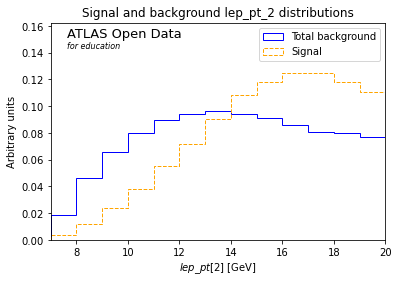

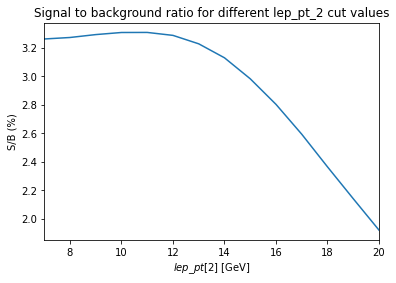

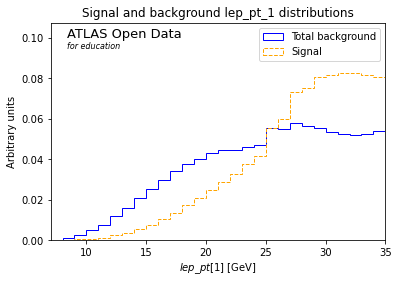

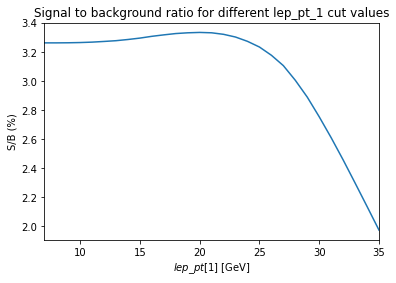

In [72]:
from my_functions import plot_SoverB

plot_SoverB(DataFrames, SoverB_hist_dict)

In [73]:
ML_inputs = ["lep_pt_0", "lep_pt_1", "lep_pt_2", "lep_pt_3"]  # list of features for ML model

In [74]:
#  Organise data ready for the machine learning model

# for sklearn data are usually organised
# into one 2D array of shape (n_samples x n_features)
# containing all the data and one array of categories
# of length n_samples

all_MC = []  # define empty list that will contain all features for the MC
for s in samples:  # loop over the different samples
    if s != "data":  # only MC should pass this
        all_MC.append(
            DataFrames[s][ML_inputs]
        )  # append the MC dataframe to the list containing all MC features
X = np.concatenate(
    all_MC
)  # concatenate the list of MC dataframes into a single 2D array of features, called X

all_y = (
    []
)  # define empty list that will contain labels whether an event in signal or background
for s in samples:  # loop over the different samples
    if s != "data":  # only MC should pass this
        if "H125" in s:  # only signal MC should pass this
            all_y.append(
                np.ones(DataFrames[s].shape[0])
            )  # signal events are labelled with 1
        else:  # only background MC should pass this
            all_y.append(
                np.zeros(DataFrames[s].shape[0])
            )  # background events are labelled 0
y = np.concatenate(
    all_y
)  # concatenate the list of labels into a single 1D array of labels, called y

In [75]:
# This will split your data into train-test sets: 67%-33%.
# It will also shuffle entries so you will not get the first 67% of X for training
# and the last 33% for testing.
# This is particularly important in cases where you load all signal events first
# and then the background events.

# Here we split our data into two independent samples.
# The split is to create a training and testing set.
# The first will be used for classifier training and the second to evaluate its performance.

from sklearn.model_selection import train_test_split

# make train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=seed_value
)  # set the random seed for reproducibility

In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()  # initialise StandardScaler

# Fit only to the training data
scaler.fit(X_train)

StandardScaler()

In [77]:
X_train_scaled = scaler.transform(X_train)

In [78]:
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.transform(X)

In [80]:
import torch  # import PyTorch
import torch.nn as nn  # import PyTorch neural network
import torch.nn.functional as F  # import PyTorch neural network functional
from torch.autograd import Variable  # create variable from tensor
import torch.utils.data as Data  # create data from tensors

In [81]:
epochs = 10  # number of training epochs
batch_size = 32  # number of samples per batch
input_size = len(ML_inputs)  # The number of features
num_classes = 2  # The number of output classes. In this case: [signal, background]
hidden_size = 5  # The number of nodes at the hidden layer
learning_rate = 0.001  # The speed of convergence
verbose = True  # flag for printing out stats at each epoch
torch.manual_seed(seed_value)  # set random seed for PyTorch

In [82]:
X_train_tensor = torch.as_tensor(
    X_train_scaled, dtype=torch.float
)  # make tensor from X_train_scaled
y_train_tensor = torch.as_tensor(y_train, dtype=torch.long)  # make tensor from y_train

X_train_var, y_train_var = Variable(X_train_tensor), Variable(
    y_train_tensor
)  # make variables from tensors

X_valid_var, y_valid_var = (
    X_train_var[:100],
    y_train_var[:100],
)  # get first 100 events for validation
X_train_nn_var, y_train_nn_var = (
    X_train_var[100:],
    y_train_var[100:],
)  # get remaining events for training

train_data = Data.TensorDataset(
    X_train_nn_var, y_train_nn_var
)  # create training dataset
valid_data = Data.TensorDataset(X_valid_var, y_valid_var)  # create validation dataset

train_loader = Data.DataLoader(
    dataset=train_data,  # PyTorch Dataset
    batch_size=batch_size,  # how many samples per batch to load
    shuffle=True,
)  # data reshuffled at every epoch

valid_loader = Data.DataLoader(
    dataset=valid_data,  # PyTorch Dataset
    batch_size=batch_size,  # how many samples per batch to load
    shuffle=True,
)  # data reshuffled at every epoch

In [83]:
class Classifier_MLP(nn.Module):  # define Multi-Layer Perceptron
    def __init__(self, in_dim, hidden_dim, out_dim):  # initialise
        super().__init__()  # lets you avoid referring to the base class explicitly

        self.h1 = nn.Linear(in_dim, hidden_dim)  # hidden layer 1
        self.out = nn.Linear(hidden_dim, out_dim)  # output layer
        self.out_dim = out_dim  # output layer dimension

    def forward(self, x):  # order of the layers

        x = F.relu(self.h1(x))  # relu activation function for hidden layer
        x = self.out(x)  # no activation function for output layer

        return x, F.softmax(x, dim=1)  # SoftMax function

In [84]:
NN_clf = Classifier_MLP(
    in_dim=input_size, hidden_dim=hidden_size, out_dim=num_classes
)  # call Classifier_MLP class
optimizer = torch.optim.SGD(
    NN_clf.parameters(), lr=learning_rate
)  # optimize model parameters

In [85]:
_results = []  # define empty list for epoch, train_loss, valid_loss, accuracy
for epoch in range(epochs):  # loop over the dataset multiple times

    # training loop for this epoch
    NN_clf.train()  # set the model into training mode

    train_loss = 0.0  # start training loss counter at 0
    for batch, (x_train_batch, y_train_batch) in enumerate(
        train_loader
    ):  # loop over train_loader

        NN_clf.zero_grad()  # set the gradients to zero before backpropragation because PyTorch accumulates the gradients
        out, prob = NN_clf(
            x_train_batch
        )  # get output and probability on this training batch
        loss = F.cross_entropy(out, y_train_batch)  # calculate loss as cross entropy

        loss.backward()  # compute dloss/dx
        optimizer.step()  # updates the parameters

        train_loss += loss.item() * x_train_batch.size(
            0
        )  # add to counter for training loss

    train_loss /= len(
        train_loader.dataset
    )  # divide train loss by length of train_loader

    if verbose:  # if verbose flag set to True
        print("Epoch: {}, Train Loss: {:4f}".format(epoch, train_loss))

    # validation loop for this epoch:
    NN_clf.eval()  # set the model into evaluation mode
    with torch.no_grad():  # turn off the gradient calculations

        correct = 0
        valid_loss = 0  # start counters for number of correct and validation loss
        for i, (x_valid_batch, y_valid_batch) in enumerate(
            valid_loader
        ):  # loop over validation loader

            out, prob = NN_clf(
                x_valid_batch
            )  # get output and probability on this validation batch
            loss = F.cross_entropy(out, y_valid_batch)  # compute loss as cross entropy

            valid_loss += loss.item() * x_valid_batch.size(
                0
            )  # add to counter for validation loss

            preds = prob.argmax(dim=1, keepdim=True)  # get predictions
            correct += (
                preds.eq(y_valid_batch.view_as(preds)).sum().item()
            )  # count number of correct

        valid_loss /= len(
            valid_loader.dataset
        )  # divide validation loss by length of validation dataset
        accuracy = correct / len(
            valid_loader.dataset
        )  # calculate accuracy as number of correct divided by total

    if verbose:  # if verbose flag set to True
        print(
            "Validation Loss: {:4f}, Validation Accuracy: {:4f}".format(
                valid_loss, accuracy
            )
        )

    # create output row:
    _results.append([epoch, train_loss, valid_loss, accuracy])

results = np.array(_results)  # make array of results
print("Finished Training")
print("Final validation error: ", 100.0 * (1 - accuracy), "%")

Epoch: 0, Train Loss: 0.458892
Validation Loss: 0.433927, Validation Accuracy: 0.710000
Epoch: 1, Train Loss: 0.417715
Validation Loss: 0.418362, Validation Accuracy: 0.710000
Epoch: 2, Train Loss: 0.413315
Validation Loss: 0.412848, Validation Accuracy: 0.720000
Epoch: 3, Train Loss: 0.411165
Validation Loss: 0.409301, Validation Accuracy: 0.720000
Epoch: 4, Train Loss: 0.409637
Validation Loss: 0.406824, Validation Accuracy: 0.720000
Epoch: 5, Train Loss: 0.408365
Validation Loss: 0.404195, Validation Accuracy: 0.720000
Epoch: 6, Train Loss: 0.407193
Validation Loss: 0.402497, Validation Accuracy: 0.720000
Epoch: 7, Train Loss: 0.406024
Validation Loss: 0.400725, Validation Accuracy: 0.720000
Epoch: 8, Train Loss: 0.404778
Validation Loss: 0.398810, Validation Accuracy: 0.730000
Epoch: 9, Train Loss: 0.403380
Validation Loss: 0.396953, Validation Accuracy: 0.730000
Finished Training
Final validation error:  27.0 %


In [86]:
X_test_tensor = torch.as_tensor(
    X_test_scaled, dtype=torch.float
)  # make tensor from X_test_scaled
y_test_tensor = torch.as_tensor(y_test, dtype=torch.long)  # make tensor from y_test

X_test_var, y_test_var = Variable(X_test_tensor), Variable(
    y_test_tensor
)  # make variables from tensors

out, prob = NN_clf(X_test_var)  # get output and probabilities from X_test
y_pred_NN = (
    prob.cpu().detach().numpy().argmax(axis=1)
)  # get signal/background predictions

In [87]:
# See how well the Neural Network classifier does
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred_NN))

0.7792117072308067


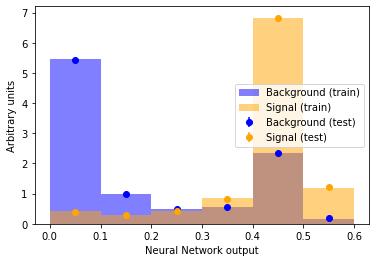

In [92]:
from my_functions import compare_train_test


compare_train_test(NN_clf, X_train_scaled, y_train, X_test_scaled, y_test, 'Neural Network output')

In [93]:
from sklearn.metrics import classification_report, roc_auc_score

# Neural Network Report
print(classification_report(y_test, y_pred_NN, target_names=["background", "signal"]))

              precision    recall  f1-score   support

  background       0.78      0.98      0.87    172891
      signal       0.68      0.12      0.21     53294

    accuracy                           0.78    226185
   macro avg       0.73      0.55      0.54    226185
weighted avg       0.76      0.78      0.71    226185



In [94]:
# Get the Neural Network signal-likeness score on the test set

decisions_nn = (
    NN_clf(X_test_var)[1][:, 1].cpu().detach().numpy()
)  # probability of signal for each event

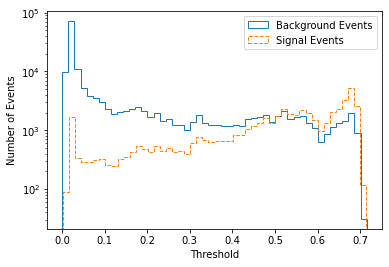

In [95]:
# Plot the Neural Network score distribution for background and signal events

plt.hist(
    decisions_nn[y_test == 0], histtype="step", bins=50, label="Background Events"
)
plt.hist(
    decisions_nn[y_test == 1],
    histtype="step",
    bins=50,
    linestyle="dashed",
    label="Signal Events",
)
plt.xlabel("Neural Network signal score")
plt.ylabel("Number of Events")
plt.semilogy()
plt.legend()

In [96]:
from sklearn.metrics import roc_curve

fpr_nn, tpr_nn, thresholds_nn = roc_curve(
    y_test, decisions_nn
)  # get FPRs, TPRs and thresholds for neural network

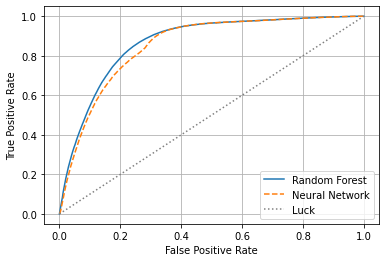

In [97]:
plt.plot(fpr_nn, tpr_nn, label="Neural Network")
plt.plot(
    [0, 1], [0, 1], linestyle="dotted", color="grey", label="Luck"
)  # diagonal line indicates random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()
plt.legend()

In [100]:
def AMS(tpr, fpr, b_reg):  # define function to calculate AMS
    return np.sqrt(2 * ((tpr + fpr + b_reg) * np.log(1 + tpr / (fpr + b_reg)) - tpr))

ams_nn = AMS(tpr_nn, fpr_nn, 0.001)  # get AMS for neural network

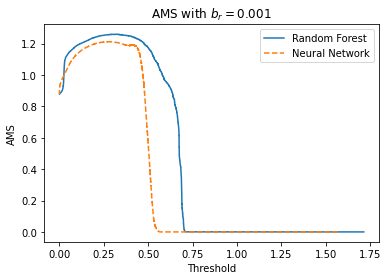

In [99]:
plt.plot(thresholds_nn, ams_nn, label="Neural Network")
plt.xlabel("Threshold")
plt.ylabel("AMS")
plt.title("AMS with $b_r=0.001$")
plt.legend()

In [104]:
DataFrames['data'] = pd.read_csv('/kaggle/input/4lepton/data.csv') # read data.csv file

In [105]:
DataFrames["data"] = DataFrames["data"][
   np.vectorize(cut_lep_type)(
       DataFrames["data"].lep_type_0,
       DataFrames["data"].lep_type_1,
       DataFrames["data"].lep_type_2,
       DataFrames["data"].lep_type_3
   )
]
DataFrames["data"] = DataFrames["data"][
   np.vectorize(cut_lep_charge)(
       DataFrames["data"].lep_charge_0,
       DataFrames["data"].lep_charge_1,
       DataFrames["data"].lep_charge_2,
       DataFrames["data"].lep_charge_3
   )
]

In [107]:
X_data = DataFrames["data"][ML_inputs].values  # .values converts straight to NumPy array

X_data_scaled = scaler.transform(X_data)  # X_data now scaled same as training and testing sets

## Higgs Peak Search Using the Trained Neural Network

Now that we have trained a signal/background neural network classifier, we use the classifier score to select Higgs-like events in `data.csv`. Then we look for a peak near 125 GeV in the four-lepton invariant mass distribution.

In [ ]:
# Step 1: Find the four-lepton invariant mass column

print("Number of columns in data:", len(DataFrames["data"].columns))
print("\nAll columns:")
for col in DataFrames["data"].columns:
    print(col)

possible_mass_columns = [
    col for col in DataFrames["data"].columns
    if ("mass" in col.lower()) or ("m4" in col.lower()) or ("llll" in col.lower()) or col.lower().startswith("m")
]

print("\nPossible mass-related columns:")
for col in possible_mass_columns:
    print(col)

In [ ]:
# Step 2: Choose the invariant mass column
# In this ATLAS 4-lepton dataset, the four-lepton invariant mass is often called "mllll".
# If your output above shows a different mass column, change mass_col manually.

preferred_mass_columns = ["mllll", "m_llll", "m4l", "m_4l", "mass_4l", "four_lepton_mass"]

mass_col = None
for candidate in preferred_mass_columns:
    if candidate in DataFrames["data"].columns:
        mass_col = candidate
        break

if mass_col is None:
    if len(possible_mass_columns) == 0:
        raise ValueError("No obvious mass column found. Please inspect DataFrames['data'].columns manually.")
    mass_col = possible_mass_columns[0]

print("Using mass column:", mass_col)
print("min:", DataFrames["data"][mass_col].min())
print("max:", DataFrames["data"][mass_col].max())
print("mean:", DataFrames["data"][mass_col].mean())

In [ ]:
# Step 3: Plot the four-lepton invariant mass before any ML score cut

plt.figure(figsize=(7, 5))
plt.hist(
    DataFrames["data"][mass_col],
    bins=45,
    range=(80, 170),
    histtype="step",
    linewidth=2,
    color="black",
    label="All selected data",
)
plt.axvline(125, color="red", linestyle="--", label="125 GeV")
plt.xlabel("Four-lepton invariant mass [GeV]")
plt.ylabel("Number of events")
plt.title("Data before ML score cut")
plt.legend()
plt.show()

In [ ]:
# Step 4: Compute Neural Network signal-likeness scores for data

X_data_tensor = torch.as_tensor(X_data_scaled, dtype=torch.float)
with torch.no_grad():
    nn_data_score = NN_clf(X_data_tensor)[1][:, 1].cpu().detach().numpy()

print("NN score range:", nn_data_score.min(), "to", nn_data_score.max())

In [ ]:
# Step 5: Apply one Neural Network score cut and compare mass distributions
# You can change this threshold to make the selection looser or tighter.

nn_threshold = 0.5
nn_signal_like = nn_data_score > nn_threshold

print("NN threshold:", nn_threshold)
print("All data events:", len(DataFrames["data"]))
print("Signal-like events after NN cut:", np.count_nonzero(nn_signal_like))

plt.figure(figsize=(7, 5))
plt.hist(
    DataFrames["data"][mass_col],
    bins=45,
    range=(80, 170),
    histtype="step",
    linewidth=2,
    color="gray",
    label="All selected data",
)
plt.hist(
    DataFrames["data"].loc[nn_signal_like, mass_col],
    bins=45,
    range=(80, 170),
    histtype="step",
    linewidth=2,
    color="tab:blue",
    label=f"NN signal-like, score > {nn_threshold}",
)
plt.axvline(125, color="red", linestyle="--", label="125 GeV")
plt.xlabel("Four-lepton invariant mass [GeV]")
plt.ylabel("Number of events")
plt.title("Higgs candidate peak after NN score cut")
plt.legend()
plt.show()

In [ ]:
# Step 6: Scan several Neural Network score thresholds
# Higher threshold = tighter signal-like selection.

thresholds_to_try = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, threshold in zip(axes, thresholds_to_try):
    selected = nn_data_score > threshold
    ax.hist(
        DataFrames["data"].loc[selected, mass_col],
        bins=30,
        range=(80, 170),
        histtype="step",
        linewidth=2,
        color="tab:blue",
    )
    ax.axvline(125, color="red", linestyle="--")
    ax.set_title(f"NN score > {threshold} ({np.count_nonzero(selected)} events)")
    ax.set_xlabel("m4l [GeV]")
    ax.set_ylabel("Events")

plt.tight_layout()
plt.show()

### Interpretation

The Neural Network score is not the Higgs mass. The score is used to select events that look signal-like. After that selection, the physics check is whether the four-lepton invariant mass distribution shows a bump near 125 GeV.